# 04 — Delivery-Time Prediction Model

Predicts how long a delivery will take (`DeliveryTimeTarget` in `order_analytics.csv`),
using only information known **before or at the moment the order is placed** — nothing
that only becomes known after the delivery finishes.

All the actual model code lives in `src/model_delivery.py` as plain functions. This
notebook just calls them in order and shows what came out.

## Which features are used, and why

**Used:** TrafficScore, RainImpact, PeakHour, IsWeekend, BasketSize, DiscountRate,
RestaurantRating, PartnerRating, DeliveryEfficiency, AverageSpeed, Temperature,
Humidity, OrderHour, DayOfWeek, RestaurantPreparationTime.

**Deliberately excluded (leakage):**
- `DeliveryTimeMinutes` / `LateDelivery` / `OrderStatus` — these directly describe
  the outcome we're trying to predict, or are derived from it.
- `CustomerRating` / `DeliveryRating` / `FoodRating` / `Sentiment` — feedback is
  only left *after* the delivery happens, so a real system wouldn't have it yet
  when trying to predict delivery time.

Missing weather/traffic readings (~46% of rows — see `feature_dictionary.md`) are
filled with the median rather than dropped; dropping half the data to avoid
imputing would throw away more signal than it protects.

## Step 1 — Load data and split into train/test

In [1]:
import sys
sys.path.insert(0, '../src')

from model_delivery import *

df = load_order_analytics("../data/analytical/order_analytics.csv")
X, y = prepare_features(df)
print("Usable orders (have a real delivery time):", len(X))

X_train, X_test, y_train, y_test = split_data(X, y)
print("Train:", len(X_train), " Test:", len(X_test))

Usable orders (have a real delivery time): 13319
Train: 10655  Test: 2664


## Step 2 — Train all 4 baseline models

In [2]:
results, fitted = train_baseline_models(X_train, y_train, X_test, y_test)
comparison = compare_models(results)
comparison

,MAE,RMSE,R2
Linear Regression,11.639,15.382,0.001
Random Forest,11.686,15.435,-0.006
Gradient Boosting,11.688,15.448,-0.008
Decision Tree,11.869,15.683,-0.039


## A note on these results

R² is essentially 0 across all four models — meaning none of them explain the
variation in delivery time meaningfully better than just predicting the average
every time. This isn't a bug in the pipeline (the feature importance below shows
the models genuinely tried, spreading weight across many features rather than
failing to run) — it's a real finding: **in this dataset, delivery time doesn't
have a strong relationship with traffic, weather, restaurant, or partner
attributes.** That's worth stating plainly in the report rather than dressing up
a weak result. Two honest explanations to mention in the writeup:
1. If this dataset was generated/simulated, delivery time may have been assigned
   close to randomly rather than driven by these factors.
2. If it's real data, the true drivers of delivery time (e.g. actual GPS route,
   real-time traffic at the exact delivery moment, kitchen backlog) simply
   aren't captured by any column available here.

## Step 3 — Tune the top 2 models only

In [3]:
top2 = comparison.index[:2].tolist()
print("Tuning:", top2)

tuned = tune_best_models(X_train, y_train, top2, n_iter=5, cv=2)

tuned_results = {}
for name, pipeline in tuned.items():
    preds = pipeline.predict(X_test)
    tuned_results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds),
    }
tuned_table = pd.DataFrame(tuned_results).T.round(3).sort_values("MAE")
tuned_table

Tuning: ['Linear Regression', 'Random Forest']


,MAE,RMSE,R2
Linear Regression,11.639,15.382,0.001
Random Forest,11.661,15.413,-0.003


## Step 4 — Save the best model, predictions, and feature importance

In [4]:
best_name = tuned_table.index[0]
best_pipeline = tuned[best_name]
print("Best model:", best_name)

save_model(best_pipeline, "../models/delivery_time_best_model.pkl")

preds = best_pipeline.predict(X_test)
pred_df = pd.DataFrame({
    "OrderID": df.loc[X_test.index, "OrderID"].values,
    "ActualDeliveryTime": y_test.values,
    "PredictedDeliveryTime": preds.round(1),
    "Residual": (y_test.values - preds).round(1),
})
pred_df.to_csv("../outputs/delivery_predictions.csv", index=False)
comparison.to_csv("../outputs/model_comparison_delivery.csv")
tuned_table.to_csv("../outputs/model_comparison_delivery_tuned.csv")

model_obj = best_pipeline.named_steps["model"]
if hasattr(model_obj, "feature_importances_") or hasattr(model_obj, "coef_"):
    fi = get_feature_importance(best_pipeline, best_name)
    fi.to_csv("../outputs/feature_importance_delivery.csv", index=False)
    print(fi.head(10))

Best model: Linear Regression
                            Feature  Importance
0            numeric__PartnerRating    0.586760
1  categorical__RainImpact_Moderate    0.585992
2             numeric__TrafficScore    0.421232
3     categorical__RainImpact_Heavy    0.332934
4           categorical__PeakHour_1    0.234521
5           categorical__PeakHour_0    0.234521
6    categorical__DayOfWeek_Unknown    0.223439
7   categorical__RainImpact_Unknown    0.219130
8     categorical__DayOfWeek_Monday    0.195816
9       numeric__DeliveryEfficiency    0.190778


## Step 5 — Actual vs predicted, and residuals

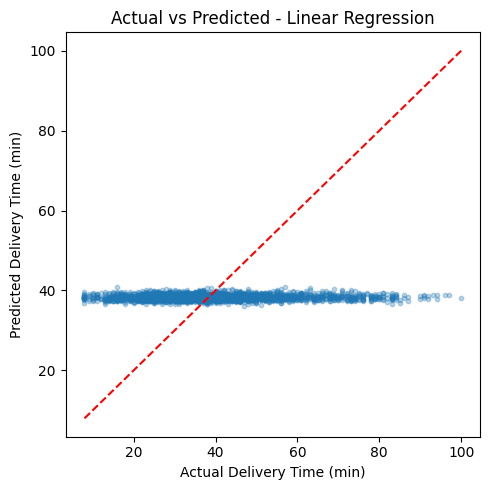

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(y_test, preds, alpha=0.3, s=10)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--')
plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("Predicted Delivery Time (min)")
plt.title(f"Actual vs Predicted - {best_name}")
plt.tight_layout()
plt.savefig("../images/ml/delivery_actual_vs_predicted.png", dpi=110)
plt.show()

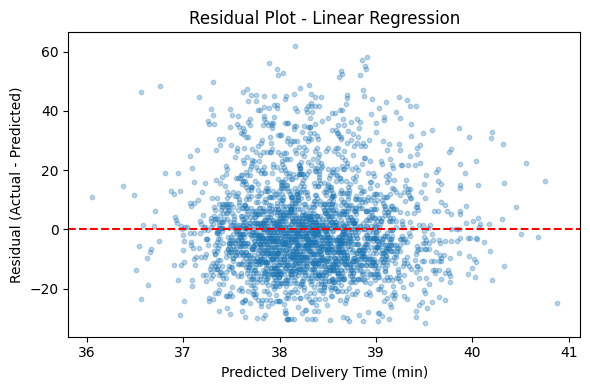

In [6]:
residuals = y_test.values - preds
plt.figure(figsize=(6,4))
plt.scatter(preds, residuals, alpha=0.3, s=10)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Delivery Time (min)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot - {best_name}")
plt.tight_layout()
plt.savefig("../images/ml/delivery_residuals.png", dpi=110)
plt.show()

## Where to go from here

- `outputs/model_comparison_delivery.csv` / `model_comparison_delivery_tuned.csv` —
  the comparison tables above, saved
- `outputs/feature_importance_delivery.csv` — full feature ranking
- `outputs/delivery_predictions.csv` — every test-set order with actual vs. predicted
- `models/delivery_time_best_model.pkl` — the saved pipeline (preprocessing + model
  bundled together — load it with `joblib.load(...)` and call `.predict()` directly
  on a DataFrame with the same feature columns)

Next up per the plan: `05_churn_model.ipynb` (classification, uses
`customer_analytics.csv`'s `Churn60` target).